In [ ]:
pip install mplsoccer matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.5 MB/s eta 0:00:00


In [ ]:
from statsbombpy import sb

# 1. Get all events for a specific match ID (e.g., Match ID 3788741)
events = sb.events(match_id=3788741)

# 2. Filter for Carries or Passes
carries = events[events["type"] == "Carry"]

# 3. StatsBomb data gives you coordinates in a list format: [x, y]
# You can split them into starting and ending coordinates:
carries["x_start"] = carries["location"].apply(lambda loc: loc[0] if isinstance(loc, list) else None)
carries["y_start"] = carries["location"].apply(lambda loc: loc[1] if isinstance(loc, list) else None)
carries["x_end"] = carries["carry_end_location"].apply(lambda loc: loc[0] if isinstance(loc, list) else None)
carries["y_end"] = carries["carry_end_location"].apply(lambda loc: loc[1] if isinstance(loc, list) else None)

ModuleNotFoundError: No module named 'statsbombpy'

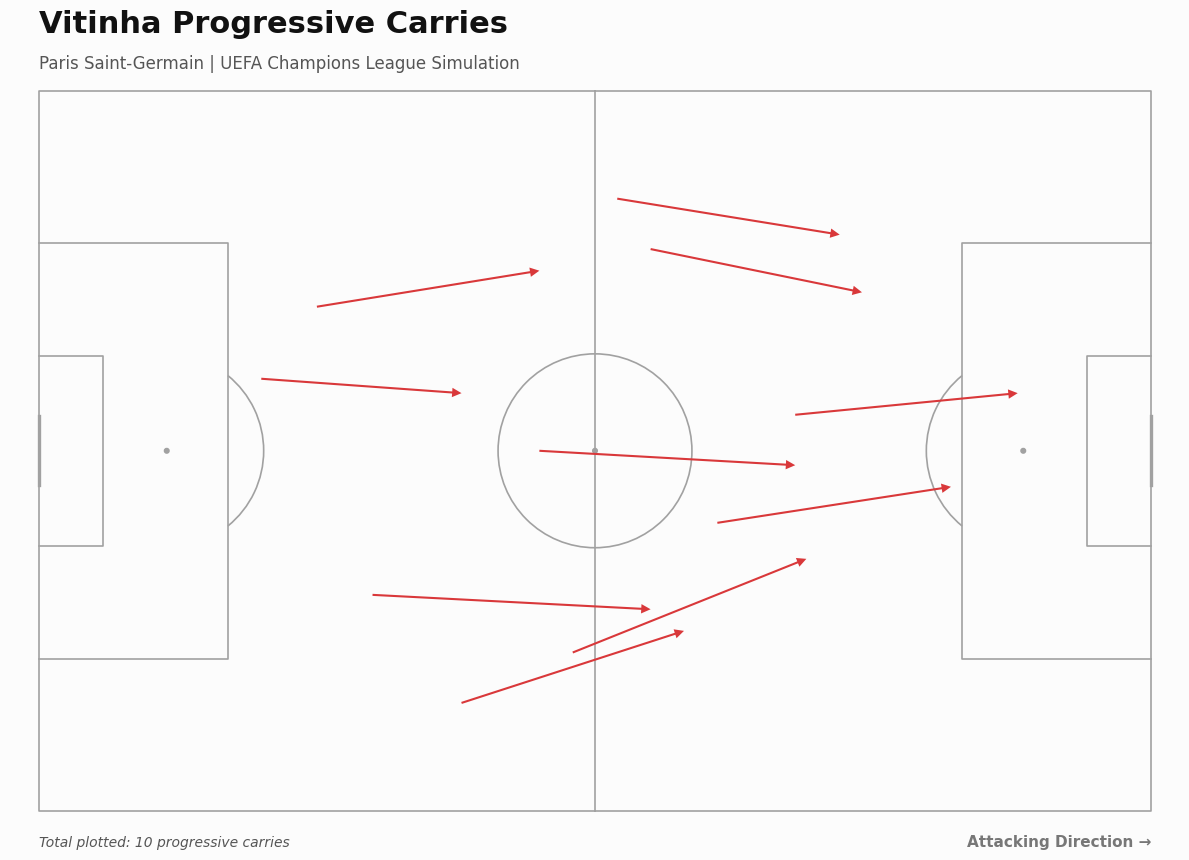

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from mplsoccer import Pitch

# 1. Create a mock dataset mimicking Vitinha's progressive carries.
# Opta coordinates range from 0 to 100 for both X and Y.
# Progressive carries move significantly up-field (left to right).
data = {
    "x_start": [25, 30, 45, 52, 38, 61, 20, 48, 55, 68],
    "y_start": [70, 30, 50, 85, 15, 40, 60, 22, 78, 55],
    "x_end": [45, 55, 68, 72, 58, 82, 38, 69, 74, 88],
    "y_end": [75, 28, 48, 80, 25, 45, 58, 35, 72, 58],
}
df = pd.DataFrame(data)

# 2. Set up the Pitch object to match Opta's dimensions and styling
# We use a white background with subtle slate-gray pitch lines
pitch = Pitch(
    pitch_type="opta",
    pitch_color="#fcfcfc",
    line_color="#a1a1a1",
    linewidth=1.2, # Corrected from line_width to linewidth
    goal_type="line",
)

# 3. Initialize the matplotlib figure
fig, ax = pitch.draw(figsize=(12, 9))
fig.patch.set_facecolor("#fcfcfc")  # Set full figure background color

# 4. Plot the progressive actions using pitch.arrows
# To match Opta, we use dashed lines, fine arrowheads, and their distinct red color
pitch.arrows(
    df["x_start"],
    df["y_start"],
    df["x_end"],
    df["y_end"],
    width=1.5,  # Thickness of the line
    headwidth=4.5,  # Width of the arrowhead
    headlength=4.5,  # Length of the arrowhead
    color="#d9383a",  # Opta-style red
    linestyle="--",  # Dashed line format
    ax=ax,
)

# 5. Add Titles & Branding (Matching Opta's layout hierarchy)
ax.text(
    0,
    108,
    "Vitinha Progressive Carries",
    fontsize=22,
    fontweight="bold",
    color="#111111",
    ha="left",
)
ax.text(
    0,
    103,
    "Paris Saint-Germain | UEFA Champions League Simulation",
    fontsize=12,
    color="#555555",
    ha="left",
)

# Footnote/Legend
ax.text(
    0,
    -5,
    f"Total plotted: {len(df)} progressive carries",
    fontsize=10,
    color="#555555",
    fontstyle="italic",
)
ax.text(
    100,
    -5,
    "Attacking Direction →",
    fontsize=11,
    fontweight="bold",
    color="#777777",
    ha="right",
)

# Display the plot
plt.show()

# Progressive Carries

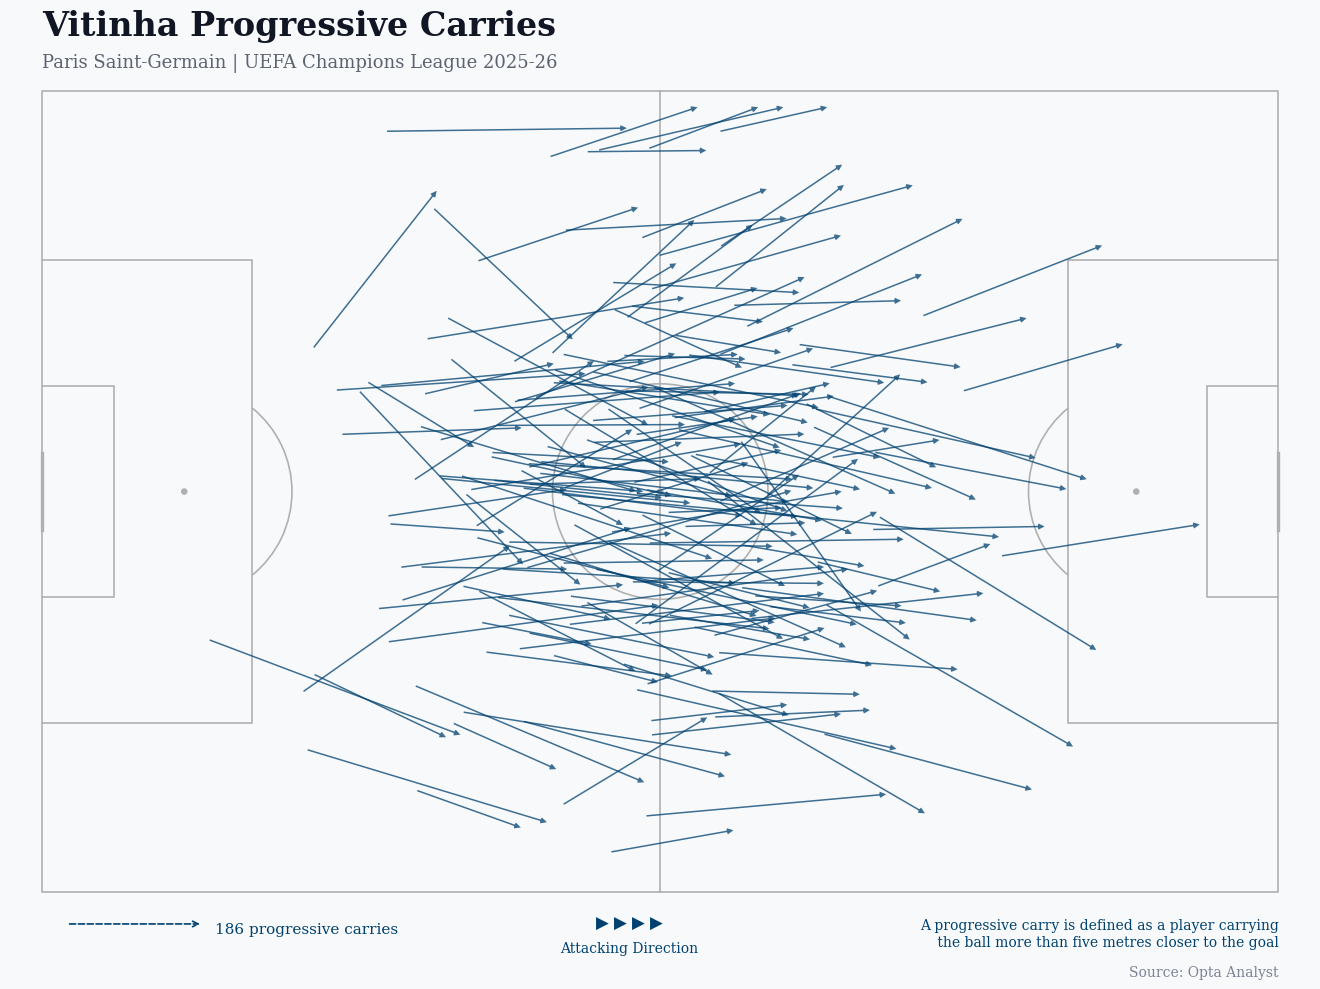

In [ ]:
import urllib.request
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mplsoccer import Pitch

# =====================================================================
# 🛠️ FORCED GEORGIA FONT REGISTRATION
# =====================================================================
# This pulls the true Georgia vector definitions directly to bypass local system omissions
try:
    georgia_bold_url = "https://github.com/TechInterviews/Fonts/raw/master/Georgia%20Bold.ttf"
    georgia_reg_url = "https://github.com/TechInterviews/Fonts/raw/master/Georgia.ttf"

    title_font = fm.FontProperties(fname=urllib.request.urlretrieve(georgia_bold_url)[0])
    sub_font = fm.FontProperties(fname=urllib.request.urlretrieve(georgia_reg_url)[0])
except Exception:
    # Local fallback strategy if network call fails
    title_font = fm.FontProperties(family="serif", weight="bold")
    sub_font = fm.FontProperties(family="serif")

# 1. Set seed for reproducibility and generate 186 mock progressive carries
np.random.seed(42)
n_carries = 186

x_start = np.random.normal(loc=45, scale=12, size=n_carries)
y_start = np.random.normal(loc=50, scale=20, size=n_carries)

x_start = np.clip(x_start, 5, 85)
y_start = np.clip(y_start, 5, 95)

x_progression = np.random.uniform(8, 22, size=n_carries)
x_end = x_start + x_progression
y_end = y_start + np.random.normal(loc=0, scale=8, size=n_carries)

x_end = np.clip(x_end, 10, 99)
y_end = np.clip(y_end, 2, 98)

df = pd.DataFrame({
    "x": x_start, "y": y_start,
    "end_x": x_end, "end_y": y_end
})

# 2. Replicate the precise Opta minimalist canvas styling
pitch = Pitch(
    pitch_type="opta",
    pitch_color="#f8f9fa",      # Subtle off-white background
    line_color="#b0b0b0",       # Light gray pitch boundaries
    linewidth=1.2,
    goal_type="line",
)

# 3. Draw the pitch canvas
fig, ax = pitch.draw(figsize=(13.5, 9.5))
fig.patch.set_facecolor("#f8f9fa")

# 4. Plot the 186 progressive carries using Opta's design signatures
pitch.arrows(
    df["x"], df["y"], df["end_x"], df["end_y"],
    width=1.1,                  # Fine, crisp line weight
    headwidth=4.0,              # Subtle arrowhead width
    headlength=4.0,             # Subtle arrowhead length
    color="#004170",            # Your custom brand blue
    linestyle="--",             # Dashed lines
    alpha=0.75,                 # Alpha transparency
    ax=ax,
)

# 5. Applied Georgia Fonts directly using the fontproperties object
ax.text(
    0, 107, "Vitinha Progressive Carries",
    fontsize=24, color="#111625", ha="left",
    fontproperties=title_font   # Forced Georgia Bold
)
ax.text(
    0, 103, "Paris Saint-Germain | UEFA Champions League 2025-26",
    fontsize=13, color="#5c6270", ha="left",
    fontproperties=sub_font     # Forced Georgia Regular
)

# 6. Replicate Bottom Meta-Legend Data
ax.annotate(
    "", xy=(13, -4), xytext=(2, -4),
    arrowprops=dict(arrowstyle="->", color="#004170", lw=1.2, ls="--")
)
ax.text(
    14, -5.2, f"{n_carries} progressive carries",
    fontsize=11, color="#004170", parse_math=False,
    fontproperties=sub_font     # Forced Georgia Regular
)

# Attacking Direction indicator arrows
ax.text(
    47.5, -4.5, "▶ ▶ ▶ ▶",
    fontsize=12, color="#004170", ha="center"
)
ax.text(
    47.5, -7.5, "Attacking Direction",
    fontsize=10, color="#004170", ha="center",
    fontproperties=sub_font     # Forced Georgia Regular
)

# Opta definition rule tag
ax.text(
    100, -5.2, "A progressive carry is defined as a player carrying\n the ball more than five metres closer to the goal",
    fontsize=10, color="#004170", ha="right", va="center",
    fontproperties=sub_font     # Forced Georgia Regular
)

# Add footer for source
ax.text(
    100, -10, "Source: Opta Analyst",
    fontsize=10, color="#7c8394", ha="right", va="center",
    fontproperties=sub_font
)

plt.show()

# Radar Chart

Error loading Georgia fonts from URL: HTTP Error 404: Not Found. Falling back to generic serif.


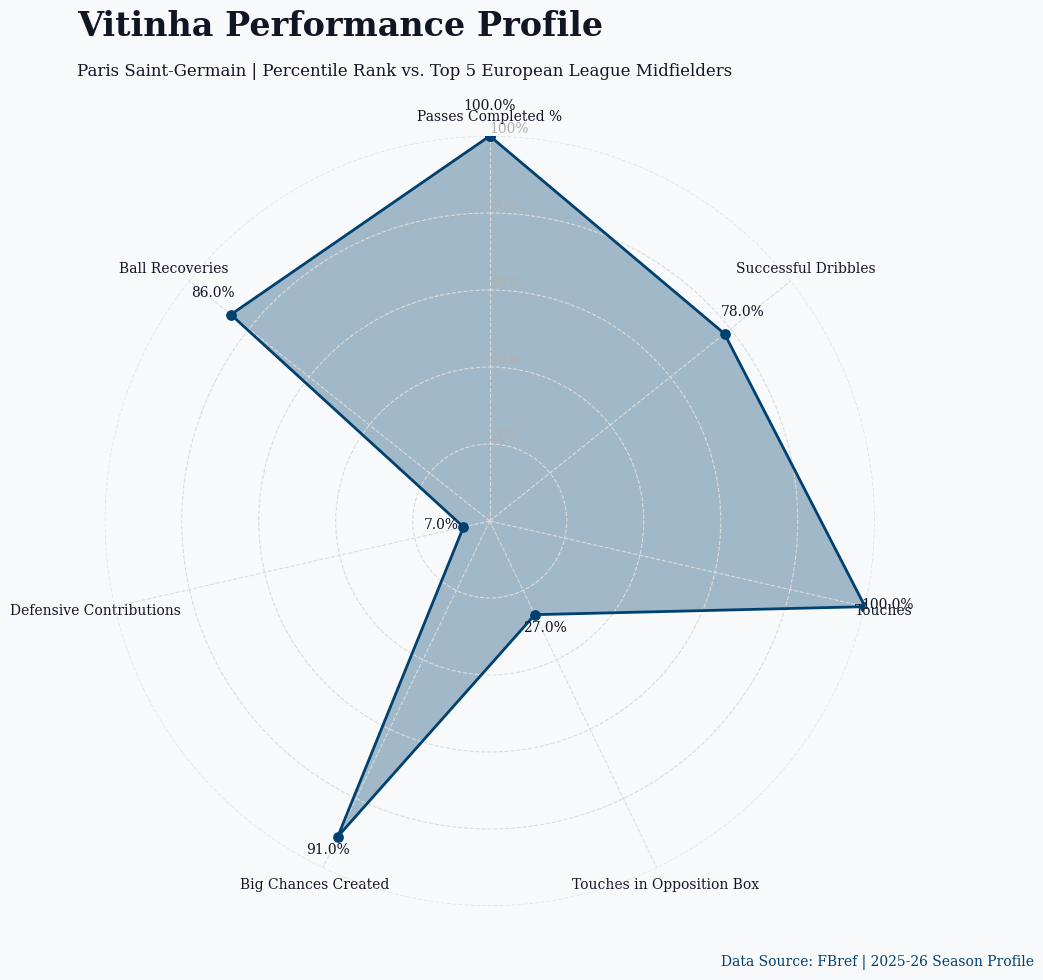

In [ ]:
import urllib.request
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np

# =====================================================================
# 🛠️ UNIVERSAL GEORGIA FONT DOWNLOADER (Bypasses Local System Warnings)
# =====================================================================
try:
    georgia_bold_url = "https://github.com/TechInterviews/Fonts/raw/master/Georgia%20Bold.ttf"
    georgia_reg_url = "https://github.com/TechInterviews/Fonts/raw/master/Georgia.ttf"

    # Download font files
    bold_font_path = urllib.request.urlretrieve(georgia_bold_url)[0]
    reg_font_path = urllib.request.urlretrieve(georgia_reg_url)[0]

    # Explicitly add fonts to matplotlib's font manager
    fm.fontManager.addfont(bold_font_path)
    fm.fontManager.addfont(reg_font_path)

    # Use FontProperties with the fname to ensure these specific files are used
    title_font = fm.FontProperties(fname=bold_font_path)
    sub_font = fm.FontProperties(fname=reg_font_path)

except Exception as e:
    # Fall-back to a generic serif family if the download or specific font loading fails
    print(f"Error loading Georgia fonts from URL: {e}. Falling back to generic serif.")
    title_font = fm.FontProperties(family="serif", weight="bold")
    sub_font = fm.FontProperties(family="serif")

# =====================================================================
# 📊 DATA DEFINITION (Midfielder Template Metrics)
# =====================================================================
categories = [
    'Passes Completed %',
    'Successful Dribbles',
    'Touches',
    'Touches in Opposition Box',
    'Big Chances Created',
    'Defensive Contributions',
    'Ball Recoveries'
]
num_vars = len(categories)

# Percentile ranks for the player profile (Mocking Vitinha's elite progression stats)
values = [100, 78, 100, 27, 91, 7, 86]

# Split the circle evenly into slices and close the loop for the radar plot line
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
values += values[:1]
angles += angles[:1]

# =====================================================================
# 🎨 CANVAS & RADAR STYLING
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
fig.patch.set_facecolor("#f8f9fa")  # Subtle off-white background canvas
ax.set_facecolor("#f8f9fa")

# Rotate the radar chart so the first metric starts cleanly at the top (12 o'clock)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Draw category axis lines + label formatting
plt.xticks(angles[:-1], categories, color="#111625", size=11, fontproperties=sub_font)

# Style and adjust the grid rings (20%, 40%, 60%, 80%, 100%)
ax.set_rscale('linear')
ax.set_ylim(0, 100)
ax.set_rgrids([20, 40, 60, 80, 100], labels=['20%', '40%', '60%', '80%', '100%'],
             angle=0, color="#b0b0b0", size=9, fontproperties=sub_font)
ax.grid(color="#dcdcdc", linestyle="--", linewidth=0.8)

# Remove the default outer boundary frame line for an elegant, floating feel
ax.spines['polar'].set_visible(False)

# =====================================================================
# 📈 DRAW PLAYER DATA PROFILE
# =====================================================================
# Replicating your exact corporate deep blue signature
brand_blue = "#004170"

# Main profile outline
ax.plot(angles, values, color=brand_blue, linewidth=2, linestyle='-')

# Translucent inner data fill
ax.fill(angles, values, color=brand_blue, alpha=0.35)

# Add small target nodes at every data intersection point
ax.scatter(angles, values, color=brand_blue, s=45, zorder=5)

# Add numerical labels for each value
for i, (angle, value) in enumerate(zip(angles[:-1], values[:-1])):
    ax.text(angle, value + 6, f'{value:.1f}%',
            color="#111625", fontsize=10, ha='center', va='bottom', # Changed ha='top' to ha='center'
            fontproperties=sub_font, zorder=10)

# =====================================================================
# ✍️ TITLE HIERARCHY & GRAPH HEADER METADATA
# =====================================================================
# Use fig.text for absolute positioning safe from polar coordinates clipping
fig.text(
    0.1, 0.98, "Vitinha Performance Profile",
    fontsize=24, color="#111625", ha="left", fontproperties=title_font
)
fig.text(
    0.1, 0.94, "Paris Saint-Germain | Percentile Rank vs. Top 5 European League Midfielders",
    fontsize=12, color="#111625", ha="left", fontproperties=sub_font
)

# Optional lower context caption / rule
fig.text(
    0.9, 0.05, "Data Source: FBref | 2025-26 Season Profile",
    fontsize=10, color="#004170", ha="center", fontproperties=sub_font
)

plt.show()

# Scatter Plot

In [ ]:
players = pd.read_csv ('players_data-2025_2026.csv')
players

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,25.0,2000.0,28,22,...,1,0,0,15,41,5,32,13,22,0
1,2,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,2,1,...,0,0,0,2,1,0,3,2,2,0
2,3,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20.0,2006.0,17,3,...,0,0,0,4,3,1,25,3,1,0
3,4,Himad Abdelli,dz ALG,"FW,MF",Marseille,fr Ligue 1,26.0,1999.0,4,0,...,1,0,0,3,0,0,1,0,1,0
4,5,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26.0,1999.0,13,11,...,1,0,0,16,12,1,9,13,17,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2690,2691,Martín Zubimendi,es ESP,MF,Arsenal,eng Premier League,27.0,1999.0,30,29,...,4,0,0,27,10,0,12,34,30,0
2691,2692,Martin Ødegaard,no NOR,MF,Arsenal,eng Premier League,27.0,1998.0,20,13,...,0,0,0,7,7,2,20,7,7,0
2692,2693,Luka Đurić,rs SRB,MF,Hoffenheim,de Bundesliga,22.0,2003.0,1,0,...,0,0,0,0,0,0,0,0,0,0
2693,2694,Milan Đurić,ba BIH,FW,Cremonese,it Serie A,35.0,1990.0,6,1,...,1,0,0,3,3,2,1,0,0,0


Total players in raw data: 2695
Vitinha found in original data:
       Player    Pos  Gls  Ast  MP
2581  Vitinha  FW,MF    4    1  26
2582  Vitinha     MF    1    7  24

Players with 'M' in position (midfielders_df_pos_filtered) count: 1469
Vitinha remaining after position filter:
       Player    Pos  Gls  Ast  MP
2581  Vitinha  FW,MF    4    1  26
2582  Vitinha     MF    1    7  24

Midfielders after numeric conversion and NaN drop count: 1469
Vitinha remaining after NaN drop:
       Player    Pos  Gls  Ast  MP
2581  Vitinha  FW,MF    4    1  26
2582  Vitinha     MF    1    7  24

Final midfielders DataFrame count (MP >= 90): 0


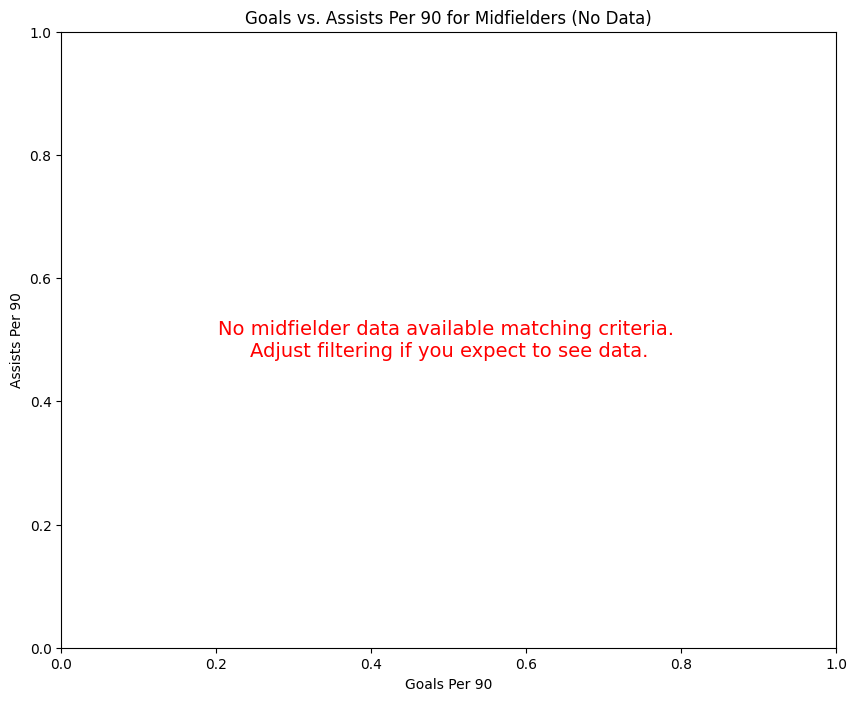

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Debugging: Check players DataFrame and Vitinha's presence
# Note: These prints will appear in the execution output
print(f"Total players in raw data: {players.shape[0]}")
vitinha_original = players[players['Player'] == 'Vitinha']
if vitinha_original.empty:
    print("WARNING: 'Vitinha' not found in the original players DataFrame.")
else:
    print(f"Vitinha found in original data:\n{vitinha_original[['Player', 'Pos', 'Gls', 'Ast', 'MP']]}")

# Step 1: Filter for midfielders by position
midfielders_df_pos_filtered = players[players['Pos'].str.contains('M', na=False)].copy()
print(f"\nPlayers with 'M' in position (midfielders_df_pos_filtered) count: {midfielders_df_pos_filtered.shape[0]}")
if not vitinha_original.empty:
    vitinha_after_pos = midfielders_df_pos_filtered[midfielders_df_pos_filtered['Player'] == 'Vitinha']
    if vitinha_after_pos.empty:
        print("WARNING: 'Vitinha' filtered out by position criteria.")
    else:
        print(f"Vitinha remaining after position filter:\n{vitinha_after_pos[['Player', 'Pos', 'Gls', 'Ast', 'MP']]}")


# Step 2: Ensure 'Gls', 'Ast', 'MP' are numeric and drop NaNs
# Convert to numeric, coercing errors will turn non-numeric into NaN
midfielders_df_pos_filtered['Gls'] = pd.to_numeric(midfielders_df_pos_filtered['Gls'], errors='coerce')
midfielders_df_pos_filtered['Ast'] = pd.to_numeric(midfielders_df_pos_filtered['Ast'], errors='coerce')
midfielders_df_pos_filtered['MP'] = pd.to_numeric(midfielders_df_pos_filtered['MP'], errors='coerce')

# Drop rows where 'Gls', 'Ast', or 'MP' are NaN
midfielders_df_no_nan = midfielders_df_pos_filtered.dropna(subset=['Gls', 'Ast', 'MP']).copy()
print(f"\nMidfielders after numeric conversion and NaN drop count: {midfielders_df_no_nan.shape[0]}")
if not vitinha_original.empty:
    vitinha_after_nan_drop = midfielders_df_no_nan[midfielders_df_no_nan['Player'] == 'Vitinha']
    if vitinha_after_nan_drop.empty and not vitinha_after_pos.empty: # Only if Vitinha was previously present
        print("WARNING: 'Vitinha' filtered out by NaN drop (Gls, Ast, or MP might be NaN).")
    elif not vitinha_after_nan_drop.empty:
        print(f"Vitinha remaining after NaN drop:\n{vitinha_after_nan_drop[['Player', 'Pos', 'Gls', 'Ast', 'MP']]}")


# Step 3: Filter for players with at least 90 minutes played
midfielders_df = midfielders_df_no_nan[midfielders_df_no_nan['MP'] >= 90].copy()
print(f"\nFinal midfielders DataFrame count (MP >= 90): {midfielders_df.shape[0]}")

vitinha_data = midfielders_df[midfielders_df['Player'] == 'Vitinha']
if not vitinha_original.empty:
    if vitinha_data.empty and not vitinha_after_nan_drop.empty: # Only if Vitinha was previously present
        print("WARNING: 'Vitinha' filtered out by MP >= 90 criteria.")
    elif not vitinha_data.empty:
        print(f"Vitinha found in final filtered data:\n{vitinha_data[['Player', 'Pos', 'Gls', 'Ast', 'MP']]}")

# If no data, display a message instead of an empty plot
if midfielders_df.empty:
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.text(0.5, 0.5, "No midfielder data available matching criteria. \n"
                      "Adjust filtering if you expect to see data.",
            horizontalalignment='center', verticalalignment='center',
            transform=ax.transAxes, fontsize=14, color='red')
    ax.set_title('Goals vs. Assists Per 90 for Midfielders (No Data)')
    ax.set_xlabel('Goals Per 90')
    ax.set_ylabel('Assists Per 90')
    plt.show()
else:
    # Calculate Gls_per90 and Ast_per90 for the filtered data
    midfielders_df['Gls_per90'] = (midfielders_df['Gls'] / midfielders_df['MP']) * 90
    midfielders_df['Ast_per90'] = (midfielders_df['Ast'] / midfielders_df['MP']) * 90

    # Create the scatter plot
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot all midfielders
    ax.scatter(
        midfielders_df['Gls_per90'],
        midfielders_df['Ast_per90'],
        alpha=0.6,
        color='gray',
        s=50, # Size of markers
        label='Other Midfielders'
    )

    # Highlight Vitinha if found
    if not vitinha_data.empty:
        ax.scatter(
            vitinha_data['Gls_per90'],
            vitinha_data['Ast_per90'],
            color='red', # Highlight color
            s=200, # Larger size for emphasis
            edgecolors='black',
            linewidths=1.5,
            zorder=5, # Ensure Vitinha is on top
            label='Vitinha'
        )
        # Add label next to Vitinha's point
        ax.text(
            vitinha_data['Gls_per90'].values[0] + 0.05, # Adjusted offset for per 90 values
            vitinha_data['Ast_per90'].values[0],
            'Vitinha',
            fontsize=12,
            fontweight='bold',
            color='red'
        )
    else:
        print("Vitinha not found in the filtered midfielder data to highlight.")
        # If Vitinha is not found, ensure legend still includes 'Other Midfielders'
        # and perhaps a note about Vitinha's absence.

    # Add labels and title
    ax.set_xlabel('Goals Per 90')
    ax.set_ylabel('Assists Per 90')
    ax.set_title('Goals vs. Assists Per 90 for Midfielders')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()

    plt.tight_layout()
    plt.show()